In [1]:
import os
import sys
sys.path.append('..')

import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.files import set_result_file_path, set_paths_file_path
from utils.namespaces import OUT_DIR
from utils.network import calc_path_weight, load_network

## 最大スロットインデックス

In [2]:
# 結果を集計するパラメータ
experiment_name         = 'scheduling_society'
network_names           = ['NSF', 'EURO16', 'JPN12', 'GRID3']
path_algo_list          = ['k-shortest-paths', 'k-shortest-paths-with-similarity-constraint', 
                           'k-dissimilar-paths', 'hierarchical-clustering']
path_weight_list        = ['hop']
sim_weight_list         = ['physical-length']
cls_distance_list       = ['single', 'average']
alpha_list              = [round(i * 0.25, 2) for i in range(1, 4)]
n_paths                 = [2, 3]

outputed_file_path = set()
multi_cols = pd.MultiIndex.from_product(
    [network_names, n_paths], names=['network_name', 'n_path']
    )
multi_idxs = pd.MultiIndex.from_product(
    [[], []], names=['algorithm', 'parameter']
)
result_df = pd.DataFrame(index=multi_idxs, columns=multi_cols)

for network_name in network_names:
    for n_path in n_paths:
        for algorithm in path_algo_list:
            for path_weight in path_weight_list:
                for sim_weight in sim_weight_list:
                    for cls_distance in cls_distance_list:
                        for alpha in alpha_list:
                            result_file_path = set_result_file_path(experiment_name, algorithm, network_name, 
                                                                    params={'path_weight': path_weight, 'sim_weight': sim_weight, 
                                                                            'alpha': alpha, 'cls_distance': cls_distance}, 
                                                                    n_paths=n_path)
                            if not os.path.exists(result_file_path) or result_file_path in outputed_file_path:
                                continue
                            outputed_file_path.add(result_file_path)
                            # エクセルファイルの読み込み
                            df = pd.read_excel(result_file_path, index_col=0)
                            # used_slots列を平均
                            mean_used_slots = df['used_slots'].mean()
                            if algorithm == 'k-shortest-paths':
                                result_df.loc[(algorithm, ''), (network_name, n_path)] = mean_used_slots
                            elif algorithm == 'k-shortest-paths-with-similarity-constraint':
                                result_df.loc[(algorithm, alpha), (network_name, n_path)] = mean_used_slots
                            elif algorithm == 'k-dissimilar-paths':
                                result_df.loc[(algorithm, ''), (network_name, n_path)] = mean_used_slots
                            elif algorithm == 'hierarchical-clustering':
                                result_df.loc[(algorithm, cls_distance), (network_name, n_path)] = mean_used_slots
                            # print(f'network_name: {network_name}, n_path: {n_path}')
                            # print(f'algorithm: {algorithm}, path_weight: {path_weight}, sim_weight: {sim_weight}, alpha: {alpha}')
                            # print(f'mean_used_slots: {mean_used_slots}')
                            # print()

result_df.to_excel(os.path.join(OUT_DIR, experiment_name, 'scheduling_society.xlsx'))
result_df.to_latex(os.path.join(OUT_DIR, experiment_name, 'scheduling_society.tex'), float_format="%.1f")
result_df.head(10)

network_name                                            NSF       EURO16  \
n_path                                                    2     3      2   
algorithm                                   parameter                      
k-shortest-paths                                       54.7  52.2   53.2   
k-shortest-paths-with-similarity-constraint 0.25       52.8  58.1   51.7   
                                            0.5        52.9  55.9   51.4   
                                            0.75       52.3  54.7   51.4   
k-dissimilar-paths                                     52.9  59.0   51.4   
hierarchical-clustering                     single     54.7  52.6   53.0   
                                            average    54.8  52.1   54.2   

network_name                                                JPN12       GRID3  \
n_path                                                    3     2     3     2   
algorithm                                   parameter                           
k-shortest-paths                                       52.1  78.0  73.4  48.4   
k-shortest-paths-with-similarity-constraint 0.25       52.8  71.8  73.8  44.0   
                                            0.5        52.5  71.9  72.9  44.0   
                                            0.75       51.3  71.9  72.0  44.0   
k-dissimilar-paths                                     70.5  71.9  77.9  44.4   
hierarchical-clustering                     single     52.0  75.2  72.4  45.2   
                                            average    52.4  77.1  72.0  46.0   

network_name                                                 
n_path                                                    3  
algorithm                                   parameter        
k-shortest-paths                                       44.0  
k-shortest-paths-with-similarity-constraint 0.25       45.6  
                                            0.5        44.0  
                                            0.75       44.0  
k-dissimilar-paths                                     46.0  
hierarchical-clustering                     single     45.2  
                                            average    44.0

In [3]:
# 結果を集計するパラメータ
experiment_name         = 'scheduling_society'
network_names           = ['NSF', 'EURO16', 'JPN12', 'GRID3']
path_algo_list          = ['k-shortest-paths', 'k-shortest-paths-with-similarity-constraint', 
                           'k-dissimilar-paths', 'hierarchical-clustering']
path_weight_list        = ['hop']
sim_weight_list         = ['physical-length']
cls_distance_list       = ['single', 'average']
alpha_list              = [round(i * 0.25, 2) for i in range(1, 4)]
n_paths                 = [2, 3]

outputed_file_path = set()
multi_cols = pd.MultiIndex.from_product(
    [network_names, n_paths], names=['network_name', 'n_path']
    )
multi_idxs = pd.MultiIndex.from_product(
    [[], []], names=['algorithm', 'parameter']
)
result_df = pd.DataFrame(index=multi_idxs, columns=multi_cols)

for network_name in network_names:
    for n_path in n_paths:
        df_used_slots = pd.DataFrame(columns=multi_idxs, index=list(range(2, 21, 2)))
        for algorithm in path_algo_list:
            for cls_distance in cls_distance_list:
                for alpha in alpha_list:
                    result_file_path = set_result_file_path(experiment_name, algorithm, network_name, 
                                                            params={'path_weight': 'hop', 'sim_weight': 'physical-length', 
                                                                    'alpha': alpha, 'cls_distance': cls_distance}, 
                                                            n_paths=n_path)
                    if not os.path.exists(result_file_path) or result_file_path in outputed_file_path:
                        continue
                    outputed_file_path.add(result_file_path)
                    # エクセルファイルの読み込み
                    df = pd.read_excel(result_file_path, index_col=0)
                    # used_slots列をdf_used_slotsに追加
                    if algorithm == 'k-shortest-paths':
                        df_used_slots.loc[:, (algorithm, '')] = df['used_slots']
                    elif algorithm == 'k-shortest-paths-with-similarity-constraint':
                        df_used_slots.loc[:, (algorithm, alpha)] = df['used_slots']
                    elif algorithm == 'k-dissimilar-paths':
                        df_used_slots.loc[:, (algorithm, '')] = df['used_slots']
                    elif algorithm == 'hierarchical-clustering':
                        df_used_slots.loc[:, (algorithm, cls_distance)] = df['used_slots']

        for column in df_used_slots.columns:
            cnt = 0
            for index in df_used_slots.index:
                # 行の最小値の場合にカウント
                if df_used_slots.loc[index, column] == df_used_slots.loc[index].min():
                    cnt += 1
            result_df.loc[column, (network_name, n_path)] = cnt
        

result_df.to_excel(os.path.join(OUT_DIR, experiment_name, 'scheduling_society_min_count.xlsx'))
result_df.to_latex(os.path.join(OUT_DIR, experiment_name, 'scheduling_society_min_count.tex'), float_format="%.1f")
result_df.head(10)

network_name                                          NSF    EURO16     JPN12  \
n_path                                                  2  3      2   3     2   
algorithm                                   parameter                           
k-shortest-paths                                        1  5      2   5     2   
k-shortest-paths-with-similarity-constraint 0.25        7  0      9   6    10   
                                            0.5         6  1     10   5     9   
                                            0.75        8  1     10  10     9   
k-dissimilar-paths                                      5  0     10   0     9   
hierarchical-clustering                     single      4  6      2   5     2   
                                            average     2  8      3   5     1   

network_name                                             GRID3      
n_path                                                 3     2   3  
algorithm                                   parameter               
k-shortest-paths                                       6     5  10  
k-shortest-paths-with-similarity-constraint 0.25       3    10   6  
                                            0.5        5    10  10  
                                            0.75       8    10  10  
k-dissimilar-paths                                     1     9   6  
hierarchical-clustering                     single     6     8   8  
                                            average    8     6  10

## 計算時間

In [4]:
# 結果を集計するパラメータ
experiment_name = 'scheduling_society'
network_names = ['NSF', 'EURO16', 'JPN12', 'GRID3']
# network_names = ['JPN12']
path_algo_list          = ['k-shortest-paths', 'k-shortest-paths-with-similarity-constraint', 
                           'k-dissimilar-paths', 'hierarchical-clustering']
# path_algo_list          = ['k-shortest-paths-with-similarity-constraint']
path_weight_list        = ['hop']
sim_weight_list         = ['physical-length']
cls_distance_list       = ['single', 'average']
alpha_list              = [round(i * 0.25, 2) for i in range(1, 4)]
n_paths                 = [2, 3]
metrics = ['Fmax', 'Runtime']

outputed_file_path = set()
# multi_cols = pd.MultiIndex.from_product([network_names, metrics, n_paths])
multi_cols = pd.MultiIndex.from_product([network_names, n_paths])
multi_idxs = pd.MultiIndex.from_product(
    [[], []], names=['algorithm', 'parameter']
)
result_time_df = pd.DataFrame(index=multi_idxs, columns=multi_cols)

for network_name in network_names:
    for n_path in n_paths:
        for algorithm in path_algo_list:
            for path_weight in path_weight_list:
                for sim_weight in sim_weight_list:
                    for cls_distance in cls_distance_list:
                        for alpha in alpha_list:
                            result_file_path = set_result_file_path(experiment_name, algorithm, network_name, 
                                                                    params={'path_weight': path_weight, 'sim_weight': sim_weight, 
                                                                            'alpha': alpha, 'cls_distance': cls_distance}, 
                                                                    n_paths=n_path)
                            if not os.path.exists(result_file_path) or result_file_path in outputed_file_path:
                                continue
                            outputed_file_path.add(result_file_path)
                            # エクセルファイルの読み込み
                            df = pd.read_excel(result_file_path, index_col=0)
                            # time(main)列に欠損がある場合エラーを出力
                            if df['time(main)'].isnull().sum() > 0:
                                print(result_file_path)
                            # time(main)列の600以上の行を600に置換
                            df.loc[df['time(main)'] > 600, 'time(main)'] = 600.0
                            # time(main)列を平均
                            mean_time_main = df['time(main)'].mean()
                            # time(lower)の30以上の行を30に置換
                            df.loc[df['time(lower)'] > 30, 'time(lower)'] = 30.0
                            # time(lower)列を平均
                            mean_time_lower = df['time(lower)'].mean()
                            # time(upper)列の120以上の行を120に置換
                            df.loc[df['time(upper)'] > 120, 'time(upper)'] = 120.0
                            # time(upper)列を平均
                            mean_time_upper = df['time(upper)'].mean()
                            # # timeを集計
                            # mean_time = mean_time_main + mean_time_lower + mean_time_upper
                            # time列に集計
                            df.loc[:, 'time'] = df['time(main)'] + df['time(lower)'] + df['time(upper)']
                            # 平均と標準偏差を計算
                            mean_time = df['time'].mean()
                            std_time = df['time'].std()
                            if algorithm == 'k-shortest-paths':
                                # result_time_df.loc[(algorithm, ''), (network_name, 'Fmax', n_path)] = mean_used_slots
                                result_time_df.loc[(algorithm, ''), (network_name, n_path)] = f'{mean_time:.1f}({std_time:.1f})'
                            elif algorithm == 'k-shortest-paths-with-similarity-constraint':
                                # result_time_df.loc[(algorithm, alpha), (network_name, 'Fmax', n_path)] = mean_used_slots
                                result_time_df.loc[(algorithm, alpha), (network_name, n_path)] = f'{mean_time:.1f}({std_time:.1f})'
                            elif algorithm == 'k-dissimilar-paths':
                                # result_time_df.loc[(algorithm, ''), (network_name, 'Fmax', n_path)] = mean_used_slots
                                result_time_df.loc[(algorithm, ''), (network_name, n_path)] = f'{mean_time:.1f}({std_time:.1f})'
                            elif algorithm == 'hierarchical-clustering':
                                # result_time_df.loc[(algorithm, cls_distance), (network_name, 'Fmax', n_path)] = mean_used_slots
                                result_time_df.loc[(algorithm, cls_distance), (network_name, n_path)] = f'{mean_time:.1f}({std_time:.1f})'
                            # print(f'network_name: {network_name}, n_path: {n_path}')
                            # print(f'algorithm: {algorithm}, path_weight: {path_weight}, sim_weight: {sim_weight}, alpha: {alpha}')
                            # print(f'mean_used_slots: {mean_used_slots}')
                            # print()

# 3列目以降を小数点1桁で四捨五入
result_time_df.iloc[:, 2:] = result_time_df.iloc[:, 2:].round(1)
result_time_df.to_excel(os.path.join(OUT_DIR, experiment_name, 'scheduling_society_time.xlsx'))
result_time_df.to_latex(os.path.join(OUT_DIR, experiment_name, 'scheduling_society_time.tex'), float_format="%.1f")
result_time_df.head(10)

NSF  \
                                                                  2   
algorithm                                   parameter                 
k-shortest-paths                                           3.7(1.4)   
k-shortest-paths-with-similarity-constraint 0.25          11.0(7.5)   
                                            0.5          11.5(18.2)   
                                            0.75           8.9(5.7)   
k-dissimilar-paths                                         7.8(5.1)   
hierarchical-clustering                     single     290.5(327.8)   
                                            average      55.5(91.2)   

                                                                     \
                                                                  3   
algorithm                                   parameter                 
k-shortest-paths                                       234.6(335.7)   
k-shortest-paths-with-similarity-constraint 0.25       650.9(218.9)   
                                            0.5        562.7(277.8)   
                                            0.75       601.3(228.6)   
k-dissimilar-paths                                      685.8(82.8)   
hierarchical-clustering                     single     425.2(344.0)   
                                            average    518.0(280.8)   

                                                             EURO16  \
                                                                  2   
algorithm                                   parameter                 
k-shortest-paths                                        76.6(226.1)   
k-shortest-paths-with-similarity-constraint 0.25         27.6(73.8)   
                                            0.5          28.7(75.2)   
                                            0.75         57.6(93.4)   
k-dissimilar-paths                                     107.3(195.2)   
hierarchical-clustering                     single     109.6(225.8)   
                                            average       6.4(10.0)   

                                                                     \
                                                                  3   
algorithm                                   parameter                 
k-shortest-paths                                       313.9(331.2)   
k-shortest-paths-with-similarity-constraint 0.25       462.2(337.8)   
                                            0.5        618.2(114.9)   
                                            0.75       249.1(211.0)   
k-dissimilar-paths                                       721.3(3.4)   
hierarchical-clustering                     single     270.5(274.7)   
                                            average    360.2(301.7)   

                                                              JPN12  \
                                                                  2   
algorithm                                   parameter                 
k-shortest-paths                                           1.9(1.2)   
k-shortest-paths-with-similarity-constraint 0.25          7.2(10.0)   
                                            0.5        112.9(222.0)   
                                            0.75       100.8(223.4)   
k-dissimilar-paths                                       19.0(39.3)   
hierarchical-clustering                     single      93.8(228.6)   
                                            average        3.6(3.3)   

                                                                     \
                                                                  3   
algorithm                                   parameter                 
k-shortest-paths                                        46.9(127.3)   
k-shortest-paths-with-similarity-constraint 0.25       280.1(322.0)   
                                            0.5        295.2(365.6)   
                                            0.75       186.0(283.3)   
k-dissimilar

## ホップ数の比較

In [5]:
# 結果を集計するパラメータ
experiment_name         = 'scheduling_society'
network_names           = ['NSF', 'EURO16', 'JPN12', 'GRID3']
path_algo_list          = ['k-shortest-paths', 'k-shortest-paths-with-similarity-constraint', 
                           'k-dissimilar-paths', 'hierarchical-clustering']
path_weight             = 'hop'
sim_weight              = 'physical-length'
cls_distance            = 'single'
alpha                   = 0.5
n_paths                 = 2

algorithm1 = 'k-shortest-paths'
algorithm2 = 'k-shortest-paths-with-similarity-constraint'
algorithm3 = 'hierarchical-clustering'
params1 = {'path_weight': path_weight}
params2 = {'path_weight': path_weight, 'sim_weight': sim_weight, 'alpha': alpha}
params3 = {'path_weight': path_weight, 'sim_weight': sim_weight, 'cls_distance': cls_distance}

algo2label = {
    'k-shortest-paths': 'kSP', 
    'k-shortest-paths-with-similarity-constraint': 'kSP\u03B1SC(\u03B1=0.5)', 
    'hierarchical-clustering': 'HC(single)'
}

algorithms = [algorithm1, algorithm2, algorithm3]
params = [params1, params2, params3]

plt.rcParams['font.size'] = 12


def box_plot_length(n_path):
    # 1x4の図を作成
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for network_name in network_names:
        network = load_network(network_name)
        nw2length = dict()
        for algorithm, param in zip(algorithms, params):
            paths_file_path = set_paths_file_path(
                algorithm, 
                network_name, 
                params={'path_weight': path_weight, 'sim_weight': sim_weight, 
                        'alpha': alpha, 'cls_distance': cls_distance}, 
                n_paths=n_path
                )
            # パスの読み込み
            with open(paths_file_path, 'rb') as f:
                all_paths = pickle.load(f)
            # パスの長さを計算
            path_lengths = np.array(
                [calc_path_weight(network, path, metrics=path_weight) 
                for k_paths in all_paths.values() for path in k_paths]
                )
            # パスの長さが1のものの数を出力
            print(f'{network_name}: {algorithm} - {len(path_lengths[path_lengths == 1])}')
            nw2length[algorithm] = path_lengths
        # 箱ひげ図を作成
        ax = axes[network_names.index(network_name)]
        ax.boxplot(
            [nw2length[algorithm] for algorithm in algorithms], 
            labels=[algo2label[algorithm] for algorithm in algorithms], 
        )
        ax.set_title(network_name, fontsize=18)
        ax.set_ylim(0, 11)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, experiment_name, f'path_length_{n_path}.png'))
    plt.close()

box_plot_length(2)
box_plot_length(3)

NSF: k-shortest-paths - 42
NSF: k-shortest-paths-with-similarity-constraint - 42
NSF: hierarchical-clustering - 42
EURO16: k-shortest-paths - 46
EURO16: k-shortest-paths-with-similarity-constraint - 46
EURO16: hierarchical-clustering - 46
JPN12: k-shortest-paths - 34
JPN12: k-shortest-paths-with-similarity-constraint - 34
JPN12: hierarchical-clustering - 34
GRID3: k-shortest-paths - 24
GRID3: k-shortest-paths-with-similarity-constraint - 24
GRID3: hierarchical-clustering - 24
NSF: k-shortest-paths - 42
NSF: k-shortest-paths-with-similarity-constraint - 42
NSF: hierarchical-clustering - 42
EURO16: k-shortest-paths - 46
EURO16: k-shortest-paths-with-similarity-constraint - 46
EURO16: hierarchical-clustering - 46
JPN12: k-shortest-paths - 34
JPN12: k-shortest-paths-with-similarity-constraint - 34
JPN12: hierarchical-clustering - 34
GRID3: k-shortest-paths - 24
GRID3: k-shortest-paths-with-similarity-constraint - 24
GRID3: hierarchical-clustering - 24


### 類似度の比較

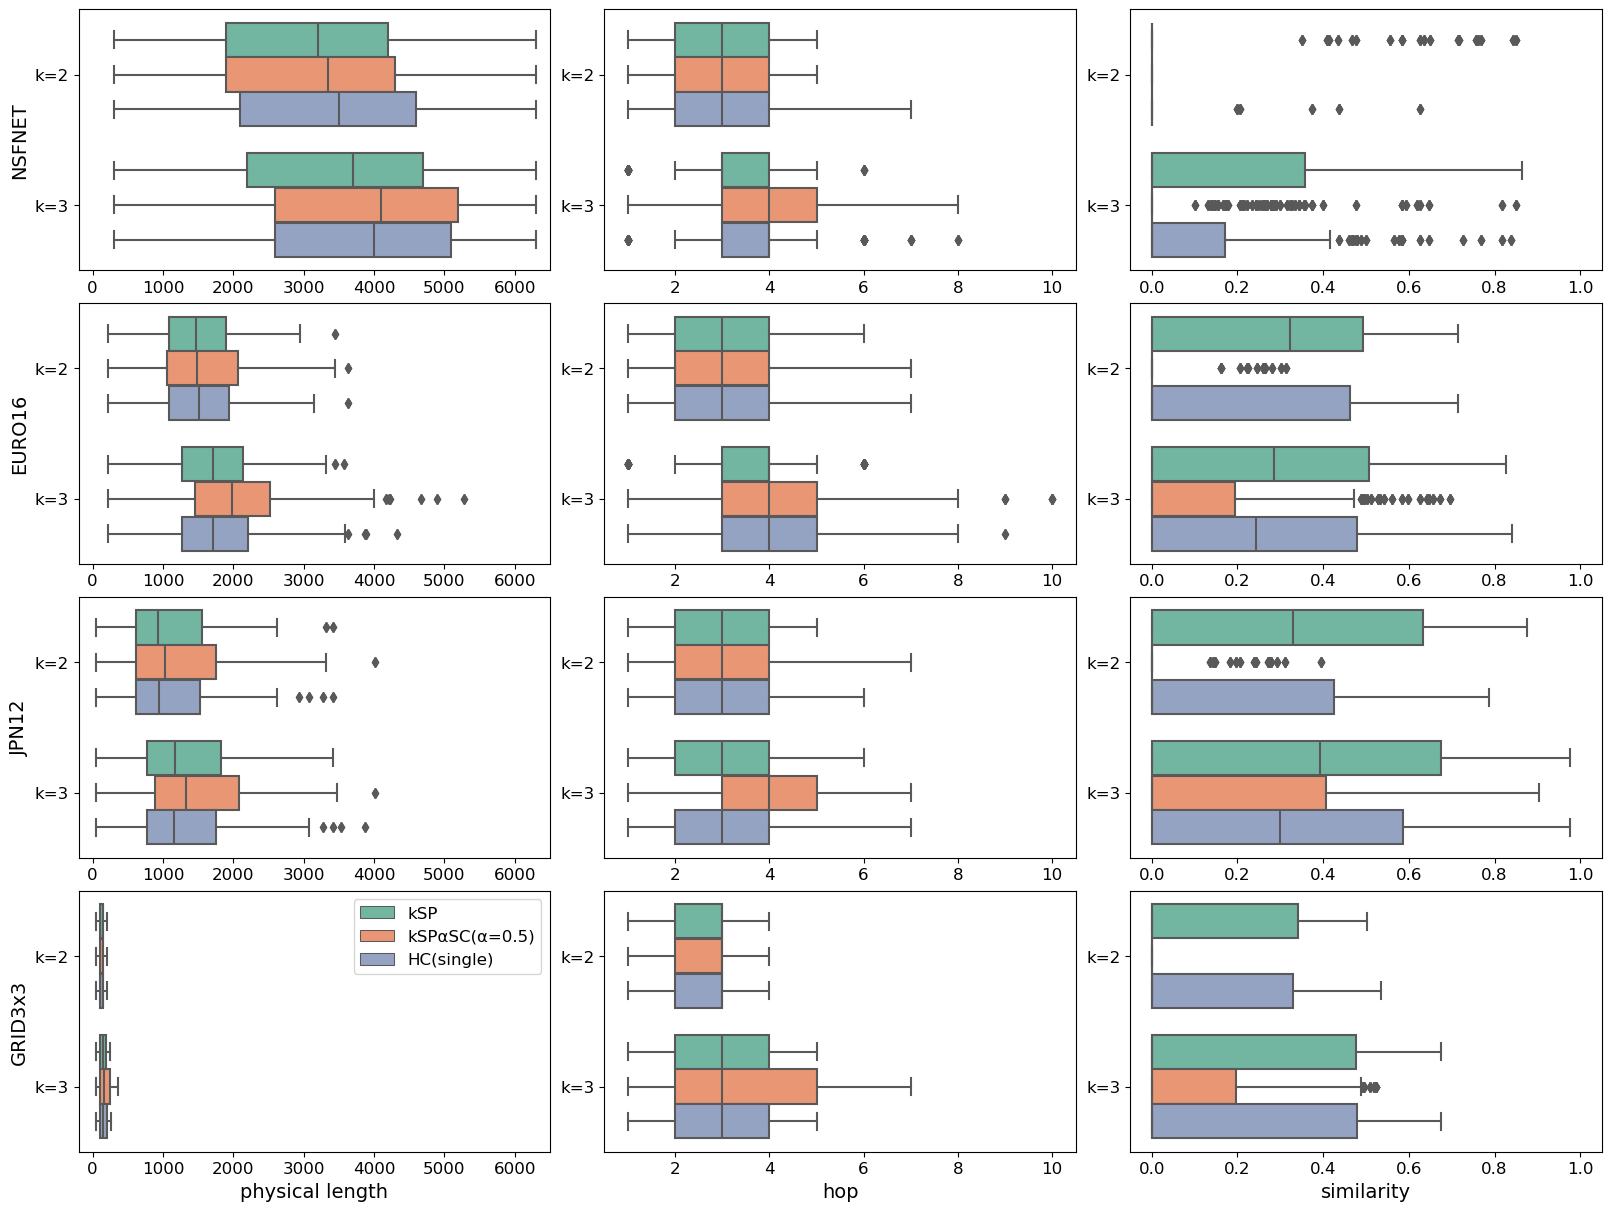

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import warnings

from utils.network import calc_path_similarity
warnings.filterwarnings('ignore')

# 結果を集計するパラメータ
experiment_name         = 'scheduling_society'
network_names           = ['NSF', 'EURO16', 'JPN12', 'GRID3']
metrics                 = ['physical length', 'hop', 'similarity']

path_weight             = 'hop'
sim_weight              = 'physical-length'
cls_distance            = 'single'
alpha                   = 0.5

algorithm1 = 'k-shortest-paths'
algorithm2 = 'k-shortest-paths-with-similarity-constraint'
algorithm3 = 'hierarchical-clustering'
params1 = {'path_weight': path_weight}
params2 = {'path_weight': path_weight, 'sim_weight': sim_weight, 'alpha': alpha}
params3 = {'path_weight': path_weight, 'sim_weight': sim_weight, 'cls_distance': cls_distance}

algorithms = [algorithm1, algorithm2, algorithm3]
params = [params1, params2, params3]

network2label = {
    'NSF': 'NSFNET', 
    'EURO16': 'EURO16', 
    'JPN12': 'JPN12', 
    'GRID3': 'GRID3x3'
}
algo2label = {
    'k-shortest-paths': 'kSP', 
    'k-shortest-paths-with-similarity-constraint': 'kSP\u03B1SC(\u03B1=0.5)', 
    'hierarchical-clustering': 'HC(single)'
}

# グラフの描画
fig, axs = plt.subplots(4, 3, figsize=(16, 12), constrained_layout=True)

# 箱ひげ図の色を指定
palette = sns.color_palette("Set2", len(algorithms))

for row, network_name in enumerate(network_names):
    for col, metric in enumerate(metrics):
        data = []
        for k in range(2, 4):
            for i, (algorithm, param) in enumerate(zip(algorithms, params)):
                paths_file_path = set_paths_file_path(
                    algorithm, 
                    network_name, 
                    params=param, 
                    n_paths=k
                )
                network = load_network(network_name)
                with open(paths_file_path, 'rb') as f:
                    all_paths = pickle.load(f)
                if metric == 'physical length':
                    vector = np.array(
                        [calc_path_weight(network, path, metrics='physical-length') 
                        for k_paths in all_paths.values() for path in k_paths]
                    )
                elif metric == 'hop':
                    vector = np.array(
                        [calc_path_weight(network, path, metrics='hop') 
                        for k_paths in all_paths.values() for path in k_paths]
                    )
                elif metric == 'similarity':
                    vector = np.array(
                        [calc_path_similarity(network, path1, path2, edge_weight='physical-length')
                         for k_paths in all_paths.values() for path1 in k_paths for path2 in k_paths 
                         if path1 != path2]
                    )
                data.extend(pd.DataFrame({
                    'k': f'k={k}',
                    metric: vector,
                    'Algorithm': algo2label[algorithm]
                }).to_dict('records'))
        
        sns.boxplot(y='k', x=metric, hue='Algorithm', data=pd.DataFrame(data), 
                    ax=axs[row, col], palette=palette)
        # データの範囲を揃える
        if metric == 'physical length':
            axs[row, col].set_xlim(-200, 6500)
        elif metric == 'hop':
            axs[row, col].set_xlim(0.5, 10.5)
        elif metric == 'similarity':
            axs[row, col].set_xlim(-0.05, 1.05)
        # ネットワークのラベル
        if col == 0:
            axs[row, col].set_ylabel(network2label[network_name], fontsize=14)
        else:
            axs[row, col].set_ylabel('')
        # 評価指標のラベル
        if row == 3:
            axs[row, col].set_xlabel(metric, fontsize=14)
        else:
            axs[row, col].set_xlabel('')
        if row == 3 and col == 0:
            axs[row, col].legend(loc='upper right')
        else:
            axs[row, col].legend().remove()

plt.savefig(os.path.join(OUT_DIR, experiment_name, 'path_metrics.pdf'))
plt.show()

## 物理的距離の比較

In [7]:
import pickle
# 結果を集計するパラメータ
experiment_name         = 'scheduling_society'
network_names           = ['NSF', 'EURO16', 'JPN12', 'GRID3']
path_algo_list          = ['k-shortest-paths', 'k-shortest-paths-with-similarity-constraint', 
                           'k-dissimilar-paths', 'hierarchical-clustering']
path_weight             = 'hop'
sim_weight              = 'physical-length'
cls_distance            = 'single'
alpha                   = 0.5

algorithm1 = 'k-shortest-paths'
algorithm2 = 'k-shortest-paths-with-similarity-constraint'
algorithm3 = 'hierarchical-clustering'
params1 = {'path_weight': path_weight}
params2 = {'path_weight': path_weight, 'sim_weight': sim_weight, 'alpha': alpha}
params3 = {'path_weight': path_weight, 'sim_weight': sim_weight, 'cls_distance': cls_distance}

algo2label = {
    'k-shortest-paths': 'kSP', 
    'k-shortest-paths-with-similarity-constraint': 'kSP\u03B1SC(\u03B1=0.5)', 
    'hierarchical-clustering': 'HC(single)'
}

algorithms = [algorithm1, algorithm2, algorithm3]
params = [params1, params2, params3]

plt.rcParams['font.size'] = 12


def box_plot_length(n_path):
    # 1x4の図を作成
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for network_name in network_names:
        network = load_network(network_name)
        nw2length = dict()
        for algorithm, param in zip(algorithms, params):
            paths_file_path = set_paths_file_path(
                algorithm, 
                network_name, 
                params={'path_weight': path_weight, 'sim_weight': sim_weight, 
                        'alpha': alpha, 'cls_distance': cls_distance}, 
                n_paths=n_path
                )
            # パスの読み込み
            with open(paths_file_path, 'rb') as f:
                all_paths = pickle.load(f)
            # パスの長さを計算
            path_lengths = np.array(
                [calc_path_weight(network, path, metrics='physical-length') 
                for k_paths in all_paths.values() for path in k_paths]
                )
            nw2length[algorithm] = path_lengths
        # 箱ひげ図を作成
        ax = axes[network_names.index(network_name)]
        ax.boxplot(
            [nw2length[algorithm] for algorithm in algorithms], 
            labels=[algo2label[algorithm] for algorithm in algorithms], 
        )
        ax.set_title(network_name, fontsize=18)
        ax.set_ylim(0, 6500)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, experiment_name, f'physical_length_{n_path}.png'))
    plt.close()

box_plot_length(2)
box_plot_length(3)